# Member 5 - Feature Selection

**Student ID:** IT25100050 
**Dataset:** Medical Insurance Dataset

## Selected Preprocessing Technique
Correlation-based exploratory feature selection.

## Explanation
Feature selection is the process of identifying predictor variables that may
provide useful information for predicting the target.

Removing unnecessary features may simplify a machine learning model and reduce
computational complexity.

## Justification
The insurance dataset contains both numerical and categorical predictor
variables.

Because Pearson correlation requires numerical values, the categorical
variables will first be temporarily one-hot encoded inside this notebook.

The relationship between each numerical feature and the target variable
`charges` will then be investigated.

Correlation measures linear association. Therefore, a low correlation does not
prove that a feature has no predictive value.

## EDA
A correlation heatmap will be used to visualize relationships between features
and insurance charges.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df_encoded = pd.get_dummies(
    df,
    columns=["sex", "smoker", "region"],
    drop_first=True,
    dtype=int
)

print("Dataset Shape After Temporary Encoding:", df_encoded.shape)

display(df_encoded.head())

Dataset Shape After Temporary Encoding: (1338, 9)


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [5]:
correlation_matrix = df_encoded.corr(
    numeric_only=True
)

target_correlation = (
    correlation_matrix["charges"]
    .drop("charges")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("Correlation of Features with Charges:")

display(target_correlation)

Correlation of Features with Charges:


smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_southwest   -0.043210
region_northwest   -0.039905
Name: charges, dtype: float64

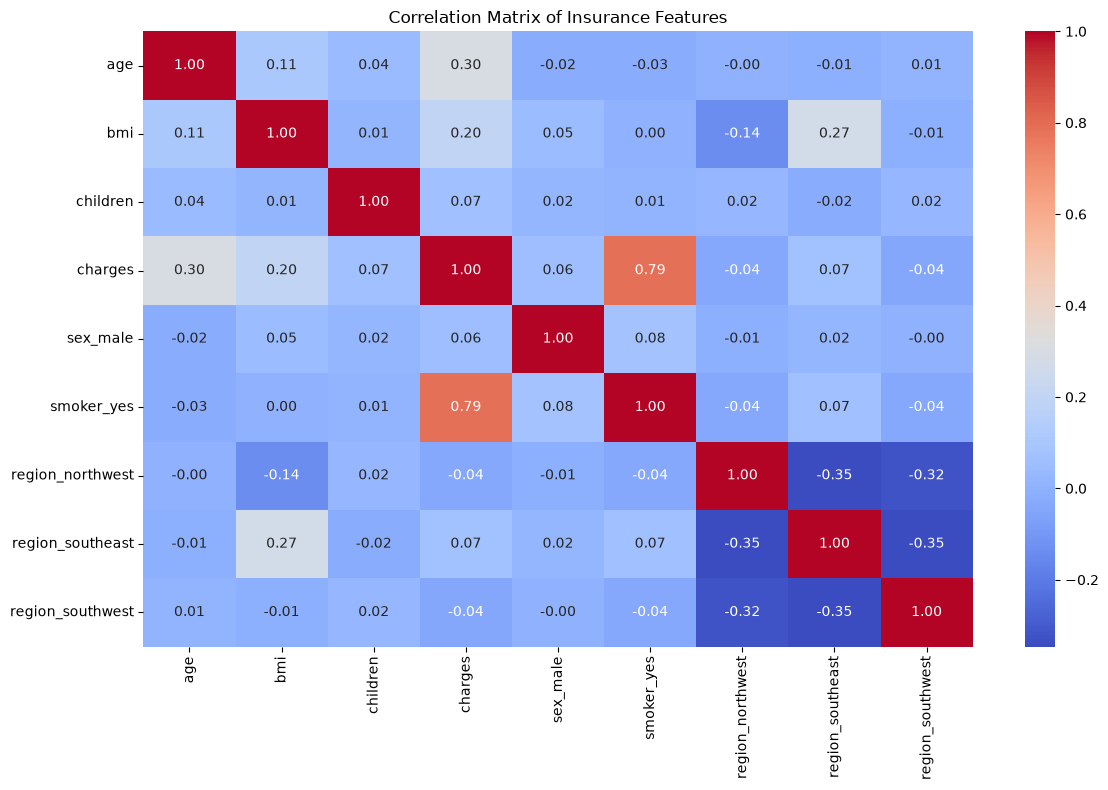

In [6]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Insurance Features")

plt.tight_layout()

plt.savefig(
    "../results/eda_visualizations/member5_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
threshold = 0.05

selected_features = target_correlation[
    target_correlation.abs() >= threshold
].index.tolist()

removed_features = target_correlation[
    target_correlation.abs() < threshold
].index.tolist()

print("Selected Features:")
print(selected_features)

print("\nFeatures Below Correlation Threshold:")
print(removed_features)

Selected Features:
['smoker_yes', 'age', 'bmi', 'region_southeast', 'children', 'sex_male']

Features Below Correlation Threshold:
['region_southwest', 'region_northwest']


In [8]:
df_selected = df_encoded[
    selected_features + ["charges"]
].copy()

print("Before Feature Selection:", df_encoded.shape)
print("After Feature Selection:", df_selected.shape)

display(df_selected.head())

Before Feature Selection: (1338, 9)
After Feature Selection: (1338, 7)


,smoker_yes,age,bmi,region_southeast,children,sex_male,charges
0,1,19,27.900,0,0,0,16884.92400
1,0,18,33.770,1,1,1,1725.55230
2,0,28,33.000,1,3,1,4449.46200
3,0,33,22.705,0,0,1,21984.47061
4,0,32,28.880,0,0,1,3866.85520


## EDA Interpretation

The correlation heatmap shows the direction and strength of linear
relationships between the numerical features and insurance charges.

Features with larger absolute correlation values have stronger linear
associations with the target in this dataset.

A threshold of 0.05 was used as a simple exploratory feature-selection rule.

However, Pearson correlation only measures linear relationships. A feature with
low correlation may still contain nonlinear or interaction-based predictive
information.

Therefore, the final usefulness of selected and removed features should also be
validated during model development.

In [9]:
df_selected.to_csv(
    "../results/outputs/member5_feature_selected.csv",
    index=False
)

print("Member 5 preprocessing completed.")

Member 5 preprocessing completed.
